# Métodos de Monte Carlo

En este ejercicio vamos a implementar la primera solución para los problemas de aprendizaje por refuerzo, los métodos de Monte Carlo. 

Recuerde que el método de Monte Carlo consiste en la colección de muestras calculando los valores para la secuencia completa de los estados hasta el estado final. Una vez se han coleccionado "suficientes" muestras, el valor de los estados se toma como el valor promedio de las muestras sobre las cuales apareció el estado.

Para resolver problemas de aprendizaje por refuerzo utilizando el método de Monte Carlo crearemos un archivo `mcm.py`. Inicialmente utilizaremos este archivo para solucionar el problema sobre el ambiente de Gridworld (suponiendo un ruido de `0.25` para las acciones, es decir que la probabilidad de ejecutar la acción deseada es de 0.75 y una acción aleatoria (dividida en partes iguales) con probabilidad de 0.25).

**Task 1**
1.	Implemente la classe `MCM` para solucionar Gridworld sin conocer los detalles del modelo de MDP para el problema. Es decir, en este caso, nuestro agente de `MCM` no tendrá acceso al `mdp` como era el caso para la iteración de valores o iteración de políticas.

2. El comportamiento del agente (de Monte Carlo) esta dado por dos momentos. El proceso de recolección de muestras y el proceso de explotación de las mismas, es decir, el cálculo de la política del agente. Usted debe implementar el comportamiento del agente dado que, ejecutando episodios como muestras, sea capaz de calcular los valores para los estados.

Para la implementación de `MCM` responda las siguientes preguntas. Tenga en cuenta que debe ejecutar su agente múltiples veces para poder observar el comportamiento (una sola instancia no nos puede llevar a ninguna conclución).
Justifique su respuestas con análisis de la ejejcución y gráficas del comportamiento.
1. ¿Cuantas muestras debe tomar el agente? Su implementación no debe utilizar este número como un parámetro o tenerlo como un factor predeterminado del agente.
2. ¿Cómo se comparan los valores de `MCM` con respecto a los valores obtenidos en el ejercicio de iteración de valores `value_iteration`? ¿Porqué se da la diferencia si existe alguna, o porqué no existe ninguna diferencia?   
3. ¿Cómo se compara la política obtenida utilizando `MCM` con respecto a la política obtenida en el jercicio de iteración de políticas `policy_iteration`? ¿Porqué se da la diferencia si existe alguna, o porqué no existe ninguna diferencia?
4. ¿Cuál es el efecto de del factor de descuento sobre el método de Monte Carlo, calcule la solución de Gridworld con diferentes valores?


In [7]:

import random

class EnvironmentNuevo:
    def __init__(self, board):
        self.board = board
        self.nrows = len(board)
        self.ncols = len(board[0]) 
        self.initial_state = self._find_initial_state()
        self.current_state = self.initial_state
        self.actions = ['up', 'right', 'down', 'left', 'exit']
        self.P = self._build_transition_matrix()
        
    def _build_transition_matrix(self):
        nA = len(self.actions)
    
        P = [[[[0 for _ in range(nA)] for _ in range(nA)]
              for _ in range(self.ncols)]
              for _ in range(self.nrows)]
    
        for i in range(self.nrows):
            for j in range(self.ncols):
            
                if self.board[i][j] == '#':
                    continue
                
                # Si es estado terminal
                if self._is_exit(i, j):
                    P[i][j][4][4] = 1.0  # exit → exit
                    continue
                
                for a in range(4):  # solo up,right,down,left
                
                    clockwise = (a + 1) % 4
                    counterclock = (a - 1) % 4
    
                    #MODIFICACION 
                    P[i][j][a][a] = 0.75
                    P[i][j][a][clockwise] = 0.125
                    P[i][j][a][counterclock] = 0.125
    
        return P


    def _find_initial_state(self):
        for i in range(self.nrows):
            for j in range(self.ncols):
                if self.board[i][j] == 'S':
                    return (i, j)
        return (0, 0)

    def get_current_state(self):
        return self.current_state

    def get_posible_actions(self, state):
        r, c = state
        if self._is_exit(r, c):
            return ['exit']
        if self.board[r][c] == '#':
            return []
        return ['up', 'right', 'down', 'left']

    def do_action(self, idx_action):
        r, c = self.current_state
    
        # Si es terminal
        if self._is_exit(r, c):
            if idx_action == 4:
                return float(self.board[r][c]), self.current_state
            return 0, self.current_state
    
        # Elegir acción real según probabilidades
        probs = self.P[r][c][idx_action]
        real_action_idx = random.choices(range(len(self.actions)), weights=probs, k=1)[0]
        real_action = self.actions[real_action_idx]
    
        nr, nc = self._move(r, c, real_action)
        self.current_state = (nr, nc)
    
        if self._is_exit(nr, nc):
            reward = float(self.board[nr][nc])
        else:
            reward = 0
    
        return reward, self.current_state



    def reset(self):
        self.current_state = self.initial_state

    def is_terminal(self):
        r, c = self.current_state
        return self._is_exit(r, c)

    def _is_exit(self, r, c):
        val = self.board[r][c]
        if isinstance(val, str):
            try:
                float(val)
                return True 
            except ValueError:
                return False
        return False

    def _move(self, r, c, action):
        dr, dc = 0, 0
        if action == 'up':
            dr = -1
        elif action == 'down':
            dr = 1
        elif action == 'left':
            dc = -1
        elif action == 'right':
            dc = 1

        nr, nc = r + dr, c + dc
        if nr < 0 or nr >= self.nrows or nc < 0 or nc >= self.ncols:
            return r, c
        if self.board[nr][nc] == '#':
            return r, c
        return nr, nc
   
gridworld = EnvironmentNuevo(
[
['S',' ',' ',' ',' ',' ',' ',' ',' ',' '],
[' ',' ',' ',' ',' ',' ',' ',' ',' ',' '],
[' ','#','#','#','#',' ','#','#','#',' '],
[' ',' ',' ',' ','#',' ',' ',' ',' ',' '],
[' ',' ',' ',' ','#','-1',' ',' ',' ',' '],
[' ',' ',' ',' ','#','+1',' ',' ',' ',' '],
[' ',' ',' ',' ','#',' ',' ',' ',' ',' '],
[' ',' ',' ',' ','#','-1','-1',' ',' ',' '],
[' ',' ',' ',' ',' ',' ',' ',' ',' ',' '],
[' ',' ',' ',' ',' ',' ',' ',' ',' ',' ']
]
)

In [ ]:
import random


class MCM:
    """
    Monte Carlo Control (First-Visit, On-Policy, ε-greedy)
    """

    def __init__(self, env, gamma=0.9, epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.995):
        self.env = env
        self.gamma = gamma

        # Parámetros de exploración
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay

        # Q(s,a)
        self.Q = {}

        # Contador de visitas N(s,a)
        self.N = {}

        # Política greedy
        self.policy = {}

        # Acciones disponibles por estado (precalculadas)
        self.actions_by_state = {}

        self._initialize()

    # ------------------------------------------
    # Inicialización
    # ------------------------------------------
    def _initialize(self):
        for i in range(self.env.nrows):
            for j in range(self.env.ncols):

                if self.env.board[i][j] == '#':
                    continue

                state = (i, j)
                actions = self.env.get_posible_actions(state)

                if not actions:
                    continue

                self.actions_by_state[state] = actions

                for a in actions:
                    self.Q[(state, a)] = 0.0
                    self.N[(state, a)] = 0

                # política inicial aleatoria
                self.policy[state] = random.choice(actions)

    # ------------------------------------------
    # ε-greedy
    # ------------------------------------------
    def _choose_action(self, state):
        actions = self.actions_by_state[state]

        # exploración
        if random.random() < self.epsilon:
            return random.choice(actions)

        # explotación
        q_values = [self.Q[(state, a)] for a in actions]
        max_q = max(q_values)

        best_actions = [a for a in actions if self.Q[(state, a)] == max_q]
        return random.choice(best_actions)

    # ------------------------------------------
    # Generar episodio
    # ------------------------------------------
    def generate_episode(self):
        episode = []

        self.env.reset()
        state = self.env.get_current_state()

        while not self.env.is_terminal():
            action = self._choose_action(state)
            action_idx = self.env.actions.index(action)

            reward, next_state = self.env.do_action(action_idx)

            episode.append((state, action, reward))
            state = next_state

        return episode

    # ------------------------------------------
    # Actualización First-Visit MC
    # ------------------------------------------
    def update(self, episode):

        G = 0
        visited = set()

        for t in reversed(range(len(episode))):
            state, action, reward = episode[t]
            G = self.gamma * G + reward

            if (state, action) not in visited:

                visited.add((state, action))

                # Incrementar contador
                self.N[(state, action)] += 1

                # Promedio incremental
                alpha = 1 / self.N[(state, action)]
                self.Q[(state, action)] += alpha * (G - self.Q[(state, action)])

                # Mejora de política (greedy)
                actions = self.actions_by_state[state]
                q_values = [self.Q[(state, a)] for a in actions]
                max_q = max(q_values)
                best_actions = [a for a in actions if self.Q[(state, a)] == max_q]
                self.policy[state] = random.choice(best_actions)

    # ------------------------------------------
    # Entrenamiento
    # ------------------------------------------
    def train(self, max_episodes=10000, stability_window=200):
        stable_count = 0
        prev_policy = None
    
        for episode in range(1, max_episodes + 1):
        
            # GLIE decay
            self.epsilon = 1 / (episode ** 0.5)
    
            episode_data = self.generate_episode()
            self.update(episode_data)
    
            # Chequeo de estabilidad de política
            current_policy = self.policy.copy()
    
            if current_policy == prev_policy:
                stable_count += 1
            else:
                stable_count = 0
    
            if stable_count >= stability_window:
                print(f"Convergió en episodio {episode}")
                return
    
            prev_policy = current_policy
    
        print("Entrenamiento terminó sin convergencia detectada")


    # ------------------------------------------
    # Obtener política final
    # ------------------------------------------
    def get_policy(self):
        return self.policy

    # ------------------------------------------
    # Obtener valores V(s)
    # ------------------------------------------
    def get_state_values(self):
        V = {}

        for state, actions in self.actions_by_state.items():
            V[state] = max(self.Q[(state, a)] for a in actions)

        return V


In [7]:
MCM_agent = MCM(gridworld)
MCM_agent.train()

Convergió en episodio 629


## v

In [5]:
def plot_policy(env, policy, title="Policy", save_path=None):
    import matplotlib.pyplot as plt
    import numpy as np

    fig, ax = plt.subplots(figsize=(6, 6))

    # Fondo base
    grid = np.zeros((env.nrows, env.ncols))
    ax.imshow(grid, cmap="Greys", alpha=0.1)

    for i in range(env.nrows):
        for j in range(env.ncols):

            cell = env.board[i][j]

            # ------------------------
            # Pared
            # ------------------------
            if cell == '#':
                ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1,
                             color='black'))
                continue

            # ------------------------
            # Terminal
            # ------------------------
            if env._is_exit(i, j):
                reward = float(cell)
                color = 'green' if reward > 0 else 'red'
                ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1,
                             color=color, alpha=0.4))
                ax.text(j, i, f"{reward}",
                        ha='center', va='center', fontsize=12, weight='bold')
                continue

            # ------------------------
            # Estado inicial
            # ------------------------
            if (i, j) == env.initial_state:
                ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1,
                             edgecolor='blue', fill=False, linewidth=2))

            # ------------------------
            # Flechas
            # ------------------------
            action = policy.get((i, j), None)

            dx, dy = 0, 0
            if action == 'up':
                dx, dy = 0, -0.3
            elif action == 'down':
                dx, dy = 0, 0.3
            elif action == 'left':
                dx, dy = -0.3, 0
            elif action == 'right':
                dx, dy = 0.3, 0

            if action:
                ax.arrow(j, i, dx, dy,
                         head_width=0.15,
                         head_length=0.15,
                         fc='blue',
                         ec='blue')

    # ------------------------
    # Estética
    # ------------------------
    ax.set_title(title)
    ax.set_xticks(np.arange(-0.5, env.ncols, 1))
    ax.set_yticks(np.arange(-0.5, env.nrows, 1))
    ax.grid(color='gray', linestyle='-', linewidth=0.5)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_xlim(-0.5, env.ncols - 0.5)
    ax.set_ylim(env.nrows - 0.5, -0.5)

    if save_path:
        plt.savefig(save_path, bbox_inches='tight')

    plt.show()


In [4]:
def plot_value_function(values, title="Value Function", save_path=None):
    import matplotlib.pyplot as plt

    plt.figure()
    plt.imshow(values)

    for i in range(len(values)):
        for j in range(len(values[0])):
            plt.text(j, i, round(values[i][j], 2),
                     ha='center', va='center')

    plt.title(title)
    plt.xticks([])
    plt.yticks([])

    if save_path:
        plt.savefig(save_path, bbox_inches='tight')

    plt.show()

import numpy as np

def values_to_matrix(env, V):
    values = np.zeros((env.nrows, env.ncols))

    for i in range(env.nrows):
        for j in range(env.ncols):
            
            if env.board[i][j] == '#':
                values[i][j] = np.nan  # para que no se dibuje
            else:
                values[i][j] = V.get((i, j), 0)

    return values


Convergió en episodio 1674


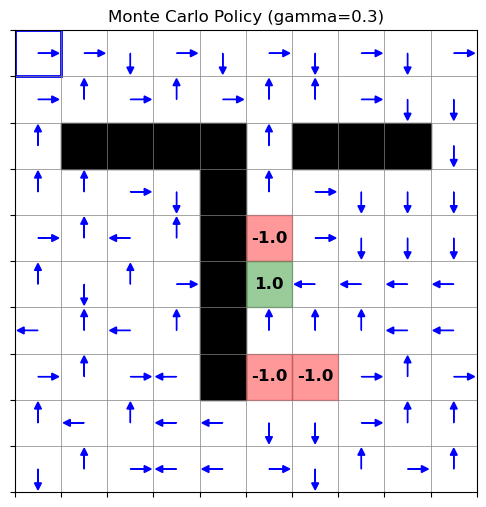

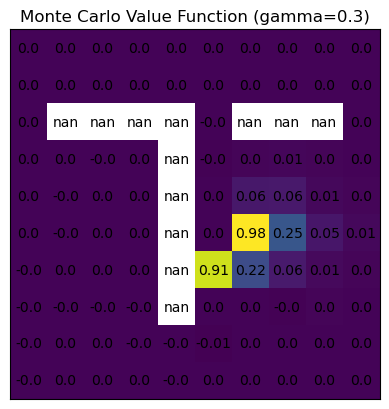

In [9]:
gridworld = EnvironmentNuevo(
[
['S',' ',' ',' ',' ',' ',' ',' ',' ',' '],
[' ',' ',' ',' ',' ',' ',' ',' ',' ',' '],
[' ','#','#','#','#',' ','#','#','#',' '],
[' ',' ',' ',' ','#',' ',' ',' ',' ',' '],
[' ',' ',' ',' ','#','-1',' ',' ',' ',' '],
[' ',' ',' ',' ','#','+1',' ',' ',' ',' '],
[' ',' ',' ',' ','#',' ',' ',' ',' ',' '],
[' ',' ',' ',' ','#','-1','-1',' ',' ',' '],
[' ',' ',' ',' ',' ',' ',' ',' ',' ',' '],
[' ',' ',' ',' ',' ',' ',' ',' ',' ',' ']
]
)
agent = MCM(gridworld, gamma=0.3)
agent.train()
policy = agent.get_policy()
plot_policy(gridworld, policy, title=f"Monte Carlo Policy (gamma={agent.gamma})", save_path="mc_policy_gamma_03.png")
V= agent.get_state_values()
values_matrix = values_to_matrix(gridworld, V)
plot_value_function(values_matrix, title=f"Monte Carlo Value Function (gamma={agent.gamma})", save_path="mc_value_gamma_03.png")

Convergió en episodio 1041


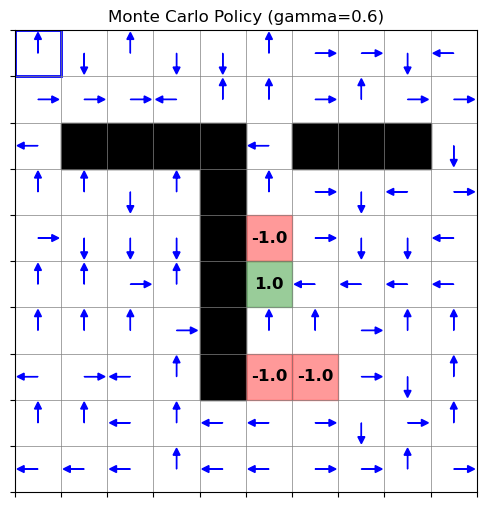

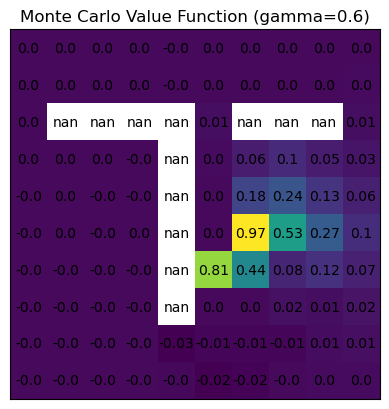

In [10]:
gridworld = EnvironmentNuevo(
[
['S',' ',' ',' ',' ',' ',' ',' ',' ',' '],
[' ',' ',' ',' ',' ',' ',' ',' ',' ',' '],
[' ','#','#','#','#',' ','#','#','#',' '],
[' ',' ',' ',' ','#',' ',' ',' ',' ',' '],
[' ',' ',' ',' ','#','-1',' ',' ',' ',' '],
[' ',' ',' ',' ','#','+1',' ',' ',' ',' '],
[' ',' ',' ',' ','#',' ',' ',' ',' ',' '],
[' ',' ',' ',' ','#','-1','-1',' ',' ',' '],
[' ',' ',' ',' ',' ',' ',' ',' ',' ',' '],
[' ',' ',' ',' ',' ',' ',' ',' ',' ',' ']
]
)
agent = MCM(gridworld, gamma=0.6)
agent.train()
policy = agent.get_policy()
plot_policy(gridworld, policy, title=f"Monte Carlo Policy (gamma={agent.gamma})", save_path="mc_policy_gamma_06.png")
V= agent.get_state_values()
values_matrix = values_to_matrix(gridworld, V)
plot_value_function(values_matrix, title=f"Monte Carlo Value Function (gamma={agent.gamma})", save_path="mc_value_gamma_06.png")

Convergió en episodio 335


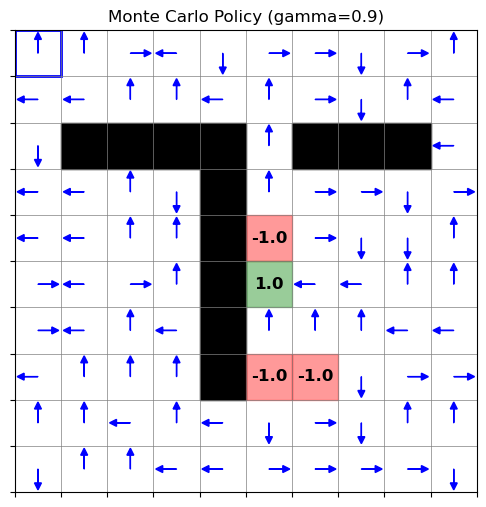

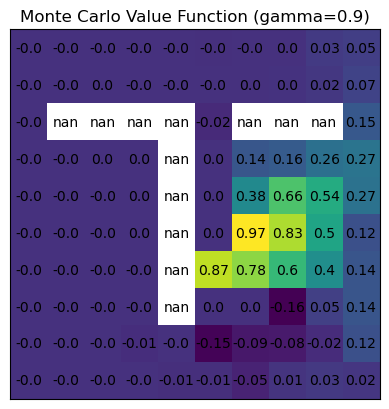

In [11]:
gridworld = EnvironmentNuevo(
[
['S',' ',' ',' ',' ',' ',' ',' ',' ',' '],
[' ',' ',' ',' ',' ',' ',' ',' ',' ',' '],
[' ','#','#','#','#',' ','#','#','#',' '],
[' ',' ',' ',' ','#',' ',' ',' ',' ',' '],
[' ',' ',' ',' ','#','-1',' ',' ',' ',' '],
[' ',' ',' ',' ','#','+1',' ',' ',' ',' '],
[' ',' ',' ',' ','#',' ',' ',' ',' ',' '],
[' ',' ',' ',' ','#','-1','-1',' ',' ',' '],
[' ',' ',' ',' ',' ',' ',' ',' ',' ',' '],
[' ',' ',' ',' ',' ',' ',' ',' ',' ',' ']
]
)
agent = MCM(gridworld, gamma=0.9)
agent.train()
policy = agent.get_policy()
plot_policy(gridworld, policy, title=f"Monte Carlo Policy (gamma={agent.gamma})", save_path="mc_policy_gamma_09.png")
V= agent.get_state_values()
values_matrix = values_to_matrix(gridworld, V)
plot_value_function(values_matrix, title=f"Monte Carlo Value Function (gamma={agent.gamma})", save_path="mc_value_gamma_09.png")

Convergió en episodio 585


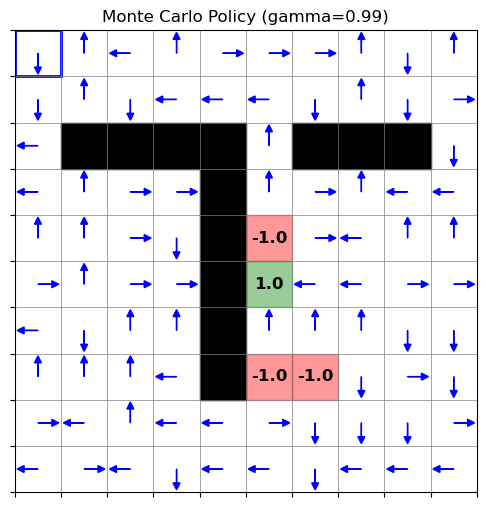

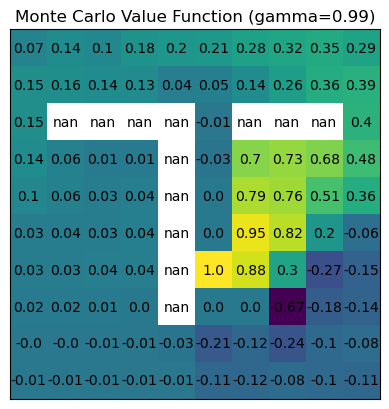

In [12]:
gridworld = EnvironmentNuevo(
[
['S',' ',' ',' ',' ',' ',' ',' ',' ',' '],
[' ',' ',' ',' ',' ',' ',' ',' ',' ',' '],
[' ','#','#','#','#',' ','#','#','#',' '],
[' ',' ',' ',' ','#',' ',' ',' ',' ',' '],
[' ',' ',' ',' ','#','-1',' ',' ',' ',' '],
[' ',' ',' ',' ','#','+1',' ',' ',' ',' '],
[' ',' ',' ',' ','#',' ',' ',' ',' ',' '],
[' ',' ',' ',' ','#','-1','-1',' ',' ',' '],
[' ',' ',' ',' ',' ',' ',' ',' ',' ',' '],
[' ',' ',' ',' ',' ',' ',' ',' ',' ',' ']
]
)
agent = MCM(gridworld, gamma=0.99)
agent.train()
policy = agent.get_policy()
plot_policy(gridworld, policy, title=f"Monte Carlo Policy (gamma={agent.gamma})", save_path="mc_policy_gamma_099.png")
V= agent.get_state_values()
values_matrix = values_to_matrix(gridworld, V)
plot_value_function(values_matrix, title=f"Monte Carlo Value Function (gamma={agent.gamma})", save_path="mc_value_gamma_099.png")